In [1]:
!pip install --upgrade biopython wordcloud transformers tf-keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 90.8 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
  Attempting uninstall: tf-keras
    Found existing installation: tf_keras 2.19.0
    Uninstalling tf_keras-2.19.0:
      Successfully uninstalled tf_keras-2.19.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstal

In [2]:
!pip uninstall -y transformers
!pip install transformers==4.41.2 tf-keras

Found existing installation: transformers 5.3.0
Uninstalling transformers-5.3.0:
  Successfully uninstalled transformers-5.3.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 74.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.5.0
    Uninstalling huggingface_hub-1.5.0:
      Successfully uninstalled huggingface_hub-1.5.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2


In [3]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import joblib
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from transformers import AutoTokenizer, TFAutoModel
from google.colab import drive

In [4]:
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/NLP_Project_Final'
WEIGHTS_DIR = os.path.join(BASE_DIR, 'Model', 'Weights')
DATA_DIR = os.path.join(BASE_DIR, 'Model', 'SplitData')
SAVE_RS = os.path.join(BASE_DIR, 'Results')

Mounted at /content/drive


In [5]:
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test_data.csv')).dropna()
X_test_raw = test_df['text'].astype(str).tolist()
y_test = test_df['label'].values
label_names = ['Case Report', 'Meta-Analysis', 'Observational Study', 'Randomized Controlled Trial']
all_metrics = {}

In [6]:
print("\n>>> [1/3] Evaluating Baseline...")
nb_model = joblib.load(os.path.join(WEIGHTS_DIR, 'baseline_nb_model.pkl'))
tfidf = joblib.load(os.path.join(WEIGHTS_DIR, 'tfidf_vectorizer.pkl'))
X_test_tfidf = tfidf.transform(X_test_raw)
all_metrics['Baseline (NB)'] = accuracy_score(y_test, nb_model.predict(X_test_tfidf))


>>> [1/3] Evaluating Baseline...


In [18]:
# --- STEP 3: BI-LSTM (KHÔI PHỤC TỪ ĐIỂN TỪ TẬP TRAIN) ---
print(">>> [2/3] Evaluating Bi-LSTM...")

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_data.csv')).dropna()
X_train_raw = train_df['text'].astype(str).tolist()

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=25000,
    output_sequence_length=311
)
vectorizer.adapt(tf.constant(X_train_raw))

def build_bilstm_final():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(311,), dtype=tf.int32),
        tf.keras.layers.Embedding(input_dim=25000, output_dim=128),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(4, activation='softmax')
    ])
    return model

model_lstm = build_bilstm_final()
model_lstm.load_weights(os.path.join(WEIGHTS_DIR, 'bilstm_best_weights.weights.h5'))

X_test_vect = vectorizer(tf.constant(X_test_raw))
y_probs_lstm = model_lstm.predict(X_test_vect, batch_size=32, verbose=0)
all_metrics['Bi-LSTM'] = accuracy_score(y_test, np.argmax(y_probs_lstm, axis=1))

print(f"==> Accuracy Bi-LSTM: {all_metrics['Bi-LSTM']*100:.2f}%")

>>> [2/3] Evaluating Bi-LSTM...
==> Accuracy Bi-LSTM: 96.27%


In [10]:
print(">>> [3/3] Evaluating SciBERT...")
TOKENIZER_NAME = 'allenai/scibert_scivocab_uncased'
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
scibert_backbone = TFAutoModel.from_pretrained(TOKENIZER_NAME, from_pt=True)

def build_scibert_final():
    input_ids = tf.keras.layers.Input(shape=(311,), dtype=tf.int32, name="input_ids")
    attention_mask = tf.keras.layers.Input(shape=(311,), dtype=tf.int32, name="attention_mask")

    bert_output = scibert_backbone(input_ids, attention_mask=attention_mask).pooler_output

    x = tf.keras.layers.Dense(128, activation='relu')(bert_output)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(4, activation='softmax')(x)

    return tf.keras.Model(inputs=[input_ids, attention_mask], outputs=outputs)

model_scibert = build_scibert_final()
weights_path = os.path.join(WEIGHTS_DIR, 'scibert_best_weights.weights.h5')
model_scibert.load_weights(weights_path)

X_test_bert = tokenizer(X_test_raw, max_length=311, padding='max_length', truncation=True, return_tensors='tf')
y_probs_bert = model_scibert.predict(
    {"input_ids": X_test_bert["input_ids"], "attention_mask": X_test_bert["attention_mask"]},
    batch_size=16, verbose=0
)
y_pred_bert = np.argmax(y_probs_bert, axis=1)
all_metrics['SciBERT'] = accuracy_score(y_test, y_pred_bert)

>>> [3/3] Evaluating SciBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch mo

/tmp/ipykernel_367/1983276641.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(all_metrics.keys()), y=list(all_metrics.values()), palette=colors)


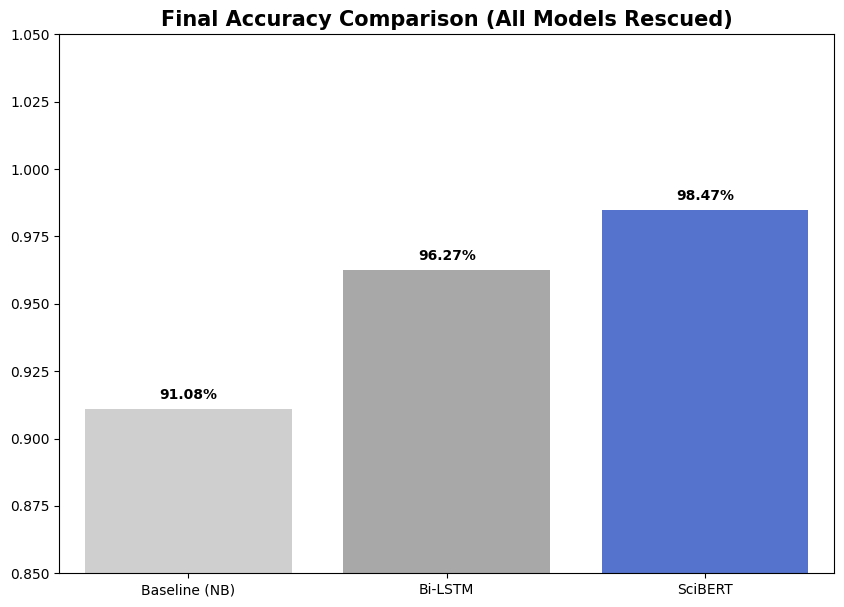


FINAL REPORT: SCIBERT (BEST MODEL)
                             precision    recall  f1-score   support

                Case Report       1.00      0.98      0.99       998
              Meta-Analysis       0.99      0.99      0.99      1000
        Observational Study       0.97      0.98      0.97       995
Randomized Controlled Trial       0.98      0.98      0.98      1000

                   accuracy                           0.98      3993
                  macro avg       0.98      0.98      0.98      3993
               weighted avg       0.98      0.98      0.98      3993



In [19]:
plt.figure(figsize=(10, 7))
colors = ['#cfcfcf', '#a8a8a8', '#4169E1']
ax = sns.barplot(x=list(all_metrics.keys()), y=list(all_metrics.values()), palette=colors)
plt.title('Final Accuracy Comparison (All Models Rescued)', fontweight='bold', fontsize=15)
plt.ylim(0.85, 1.05)

for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.savefig(os.path.join(SAVE_RS, 'final_comparison_official.png'), dpi=300)
plt.show()

print("\n" + "="*50)
print("FINAL REPORT: SCIBERT (BEST MODEL)")
print("="*50)
print(classification_report(y_test, y_pred_bert, target_names=label_names))

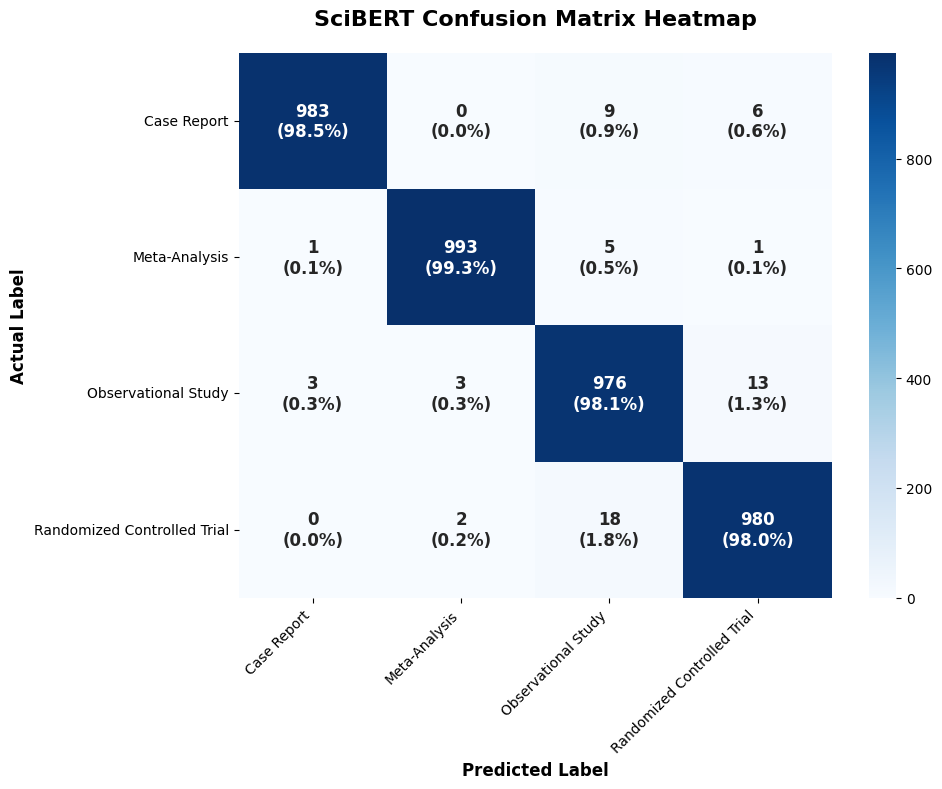

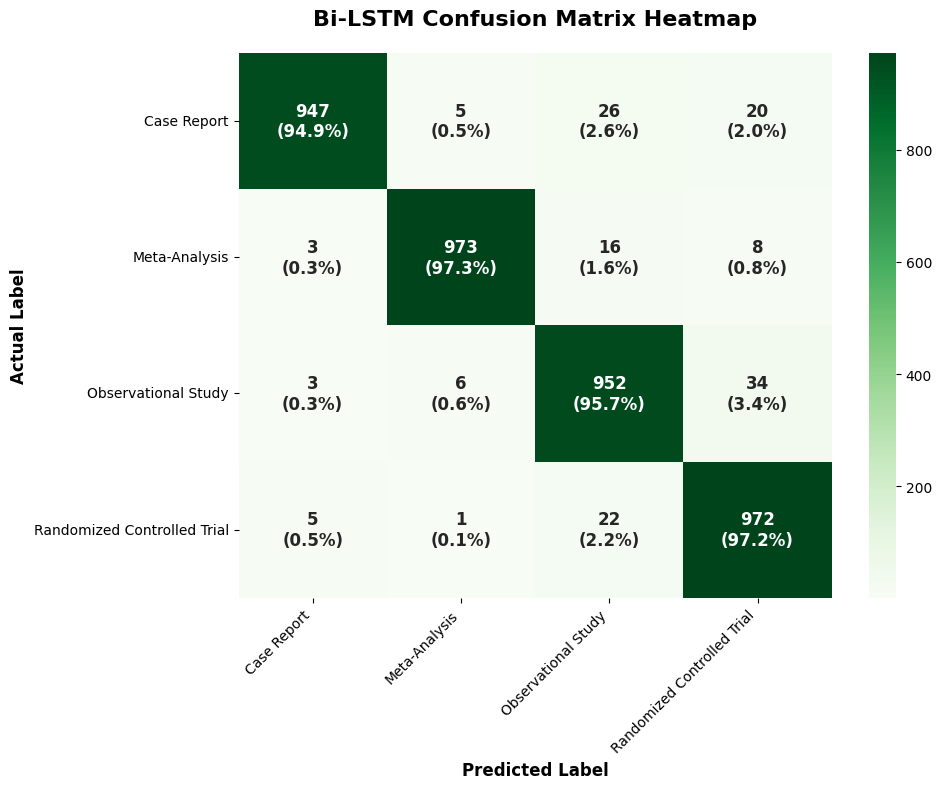

>>> Đã lưu các biểu đồ Heatmap vào: /content/drive/MyDrive/NLP_Project_Final/Results


In [20]:
def plot_confusion_matrix(y_true, y_pred, title, file_name, color='Blues'):
    cm = confusion_matrix(y_true, y_pred)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(10, 8))
    labels = [f"{v}\n({p:.1f}%)" for v, p in zip(cm.flatten(), cm_perc.flatten())]
    labels = np.asarray(labels).reshape(4, 4)

    sns.heatmap(cm, annot=labels, fmt="", cmap=color,
                xticklabels=label_names, yticklabels=label_names,
                cbar=True, annot_kws={"size": 12, "weight": "bold"})

    plt.title(title, fontweight='bold', fontsize=16, pad=20)
    plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    plt.savefig(os.path.join(SAVE_RS, file_name), dpi=300)
    plt.show()

plot_confusion_matrix(y_test, y_pred_bert,
                      'SciBERT Confusion Matrix Heatmap',
                      'heatmap_scibert.png', color='Blues')

y_pred_lstm = np.argmax(y_probs_lstm, axis=1)
plot_confusion_matrix(y_test, y_pred_lstm,
                      'Bi-LSTM Confusion Matrix Heatmap',
                      'heatmap_bilstm.png', color='Greens')

print(f">>> Đã lưu các biểu đồ Heatmap vào: {SAVE_RS}")

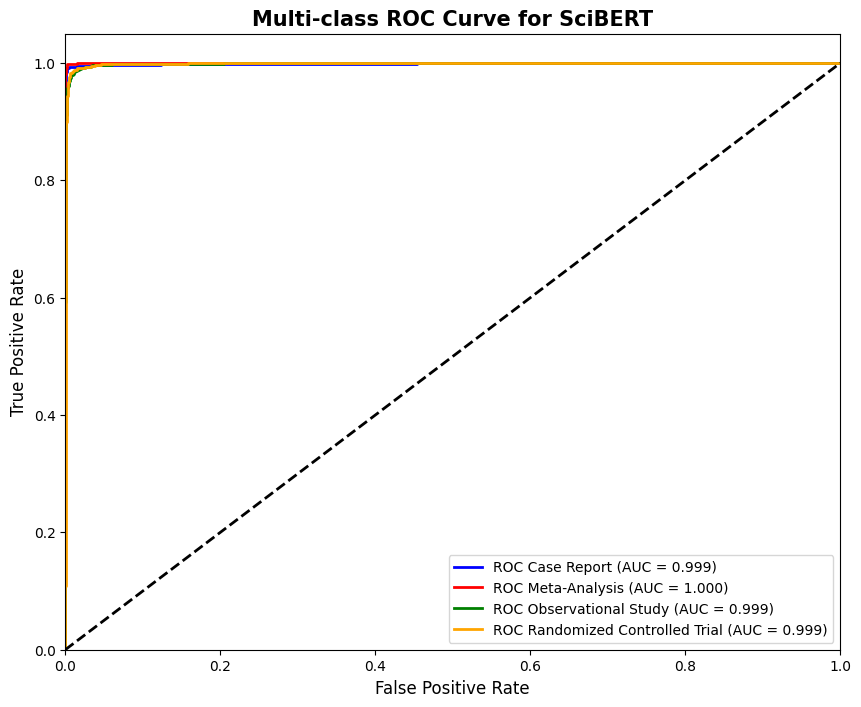

In [22]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = 4

plt.figure(figsize=(10, 8))
colors_roc = ['blue', 'red', 'green', 'orange']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs_bert[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors_roc[i], lw=2,
             label=f'ROC {label_names[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-class ROC Curve for SciBERT', fontweight='bold', fontsize=15)
plt.legend(loc="lower right")
plt.savefig(os.path.join(SAVE_RS, 'roc_curve_scibert.png'), dpi=300)
plt.show()

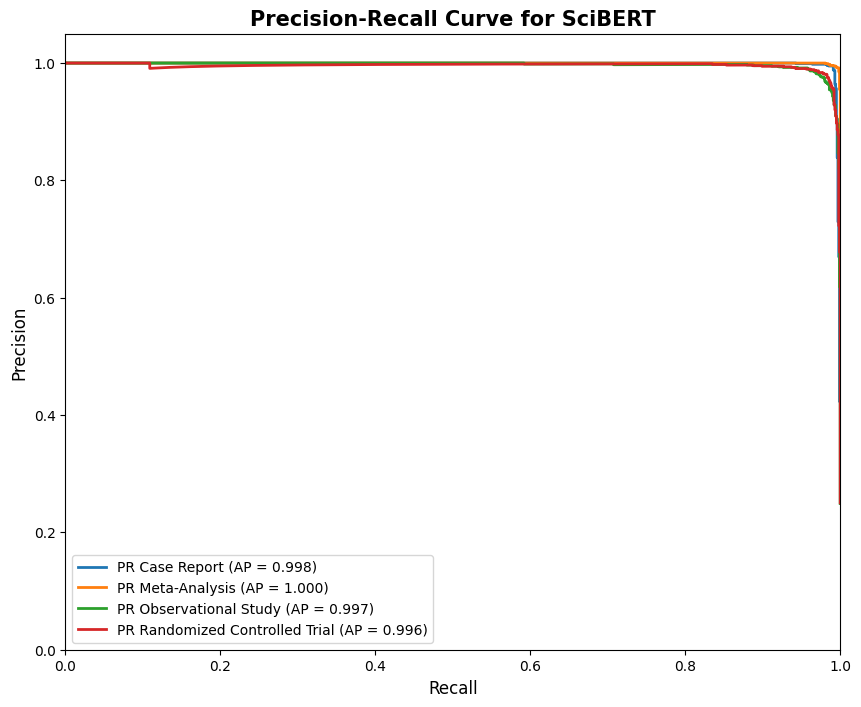

In [24]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_probs_bert[:, i])
    average_precision = average_precision_score(y_test_bin[:, i], y_probs_bert[:, i])
    plt.plot(recall, precision, lw=2,
             label=f'PR {label_names[i]} (AP = {average_precision:.3f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve for SciBERT', fontweight='bold', fontsize=15)
plt.legend(loc="lower left")
plt.savefig(os.path.join(SAVE_RS, 'precision_recall_scibert.png'), dpi=300)
plt.show()